# Flujo completo de rigor analítico: de la batería de modelos a SHAP

Este cuaderno muestra, de punta a punta, cómo cumplir los requisitos técnicos de las etapas 3 y 4 de la [ruta del proyecto](../guias/ruta-del-proyecto.md) con el [código de apoyo](../codigo/README.md) del repositorio:

1. Batería de modelos con validación cruzada repetida y `metricas_por_particion.csv`.
2. Comparación estadística: Friedman, Nemenyi con diagrama de diferencia crítica y Wilcoxon-Holm.
3. Intervalos de confianza del 95 % (bootstrap en prueba y corregidos sobre particiones).
4. Tabla de ablación.
5. Explicabilidad con SHAP contrastada con la importancia por permutación.

**Datos:** se usa el conjunto *Breast Cancer Wisconsin* que trae scikit-learn, solo para que el cuaderno corra en cualquier lugar sin descargar nada. Es un dataset de práctica: **en tu proyecto usa datos reales** de tu problema.

**Para ejecutarlo en Colab:** abre `colab.research.google.com/github/andressolispino/recursos-proyectos-analitica/blob/main/notebooks/01_flujo_rigor_analitico.ipynb` y ejecuta todas las celdas. La primera descarga el código de apoyo.

In [1]:
# Preparación: en Colab descarga el repositorio para usar el código de apoyo
import os, sys
if not os.path.exists("../codigo") and not os.path.exists("codigo"):
    !git clone -q https://github.com/andressolispino/recursos-proyectos-analitica.git
    os.chdir("recursos-proyectos-analitica")
sys.path.insert(0, os.path.abspath("../codigo" if os.path.exists("../codigo") else "codigo"))
try:
    import shap  # noqa: F401
except ImportError:
    !pip install -q shap

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

SEMILLA = 42
np.random.seed(SEMILLA)
print("Código de apoyo listo.")

Código de apoyo listo.


## 1. Datos y partición

Primero se separa el conjunto de **prueba** (20 %, estratificado). No se toca hasta el final: toda la comparación de modelos se hace con validación cruzada sobre entrenamiento.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEMILLA)

print(f"Entrenamiento: {X_train.shape}, prueba: {X_test.shape}")
print("Frecuencia de clases (entrenamiento):", y_train.value_counts(normalize=True).round(3).to_dict())
assert set(X_train.index).isdisjoint(X_test.index), "entrenamiento y prueba comparten filas"

Entrenamiento: (455, 30), prueba: (114, 30)
Frecuencia de clases (entrenamiento): {1: 0.626, 0: 0.374}


## 2. Protocolo de evaluación (fijado antes de modelar)

| Elemento | Decisión |
| --- | --- |
| Métrica principal | F1-macro |
| Métricas secundarias | AUC-ROC y MCC |
| Partición y validación | 20 % de prueba; validación cruzada estratificada repetida 5×2 sobre entrenamiento |
| Línea base | Predecir la clase más frecuente (`DummyClassifier`) |
| Criterio de éxito | Superar la línea base en F1-macro con intervalos de confianza que no se crucen |
| Prueba estadística | Friedman con Nemenyi; Wilcoxon con corrección de Holm por pares |

Todo el preprocesamiento (aquí, el escalado) va **dentro de cada Pipeline**, para que se ajuste solo con los datos de entrenamiento de cada partición.

## 3. Batería de modelos con validación repetida

In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from bateria_modelos import esquema_validacion, evaluar_bateria, tabla_media_de

modelos = {
    "Línea base": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "SVM": make_pipeline(StandardScaler(), SVC()),
    "Árbol de decisión": DecisionTreeClassifier(random_state=SEMILLA),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEMILLA),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=SEMILLA),
}
cv = esquema_validacion("clasificacion", n_splits=5, n_repeats=2, semilla=SEMILLA)
resumen, por_particion = evaluar_bateria(
    modelos, X_train, y_train, cv, metricas=["f1_macro", "roc_auc", "matthews_corrcoef"])

assert len(por_particion) == len(modelos) * 10 * 3
tabla_media_de(resumen, "f1_macro")

,modelo,f1_macro,tiempo_ajuste_s
0,Regresión logística,0.972 ± 0.011,0.005
1,SVM,0.967 ± 0.014,0.006
2,Gradient Boosting,0.965 ± 0.017,0.138
3,KNN,0.962 ± 0.02,0.004
4,Random Forest,0.961 ± 0.017,0.430
5,Árbol de decisión,0.903 ± 0.027,0.006
6,Línea base,0.385 ± 0.0,0.001


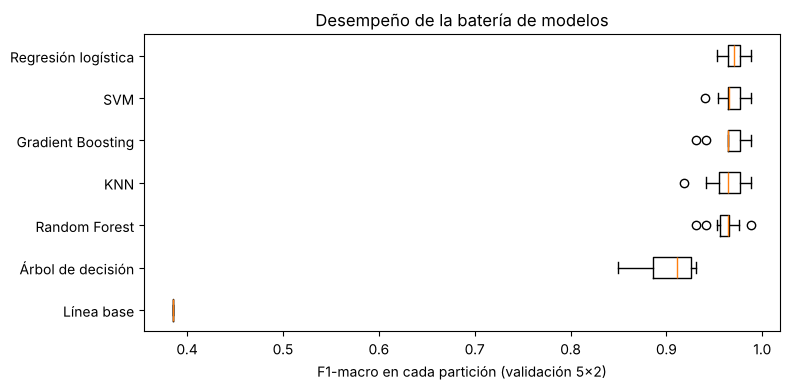

In [4]:
# Figura que compara todos los modelos (distribución de F1-macro en las 10 particiones)
f1 = por_particion[por_particion["metrica"] == "f1_macro"]
orden = f1.groupby("modelo")["valor"].mean().sort_values().index
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([f1.loc[f1["modelo"] == m, "valor"] for m in orden], vert=False)
ax.set_yticks(range(1, len(orden) + 1), orden)
ax.set_xlabel("F1-macro en cada partición (validación 5×2)")
ax.set_title("Desempeño de la batería de modelos")
fig.tight_layout()
os.makedirs("results/figures", exist_ok=True)
fig.savefig("results/figures/comparacion_modelos.png", dpi=300)
plt.show()

## 4. Comparación estadística

¿Las diferencias entre modelos son reales o pueden deberse al azar de las particiones?

In [5]:
from comparacion_estadistica import (matriz_desempeno, friedman, nemenyi,
                                     diagrama_diferencia_critica, wilcoxon_holm, reporte_texto)

M = matriz_desempeno("results/tables/metricas_por_particion.csv", "f1_macro")
fr = friedman(M, mayor_es_mejor=True)
cd = nemenyi(fr["rangos_promedio"], n_bloques=fr["n_bloques"])
print(reporte_texto(fr, cd))
fr["rangos_promedio"].round(2)

La prueba de Friedman (χ² = 40.84, k = 7, N = 10 particiones, p = 0.0000) indica que se rechaza la hipótesis de igual desempeño entre los modelos (α = 0.05). El mejor rango promedio fue SVM (2.65); la diferencia crítica de Nemenyi es CD = 2.85.


modelo
SVM                    2.65
Regresión logística    2.70
Gradient Boosting      3.15
KNN                    3.15
Random Forest          3.35
Árbol de decisión      6.00
Línea base             7.00
dtype: float64

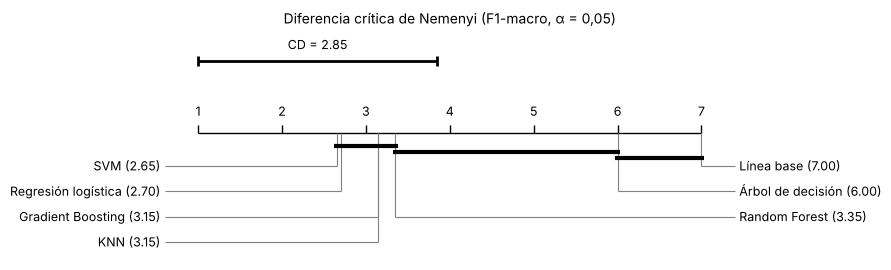

In [6]:
diagrama_diferencia_critica(fr["rangos_promedio"], cd, "results/figures/diferencia_critica.png",
                            titulo="Diferencia crítica de Nemenyi (F1-macro, α = 0,05)")
plt.show()

Los modelos unidos por una barra gruesa **no** difieren significativamente. Como complemento, la comparación por pares:

In [7]:
pares = wilcoxon_holm(M, mayor_es_mejor=True)
pares.round(4).head(10)

,modelo_a,modelo_b,mediana_diferencia_a_menos_b,estadistico_W,p_valor,mejor_segun_mediana,p_holm,diferencia_significativa
0,Gradient Boosting,Línea base,0.5794,0.0,0.002,Gradient Boosting,0.041,True
1,Gradient Boosting,Árbol de decisión,0.0610,0.0,0.002,Gradient Boosting,0.041,True
2,KNN,Línea base,0.5790,0.0,0.002,KNN,0.041,True
3,Línea base,Árbol de decisión,-0.5260,0.0,0.002,Árbol de decisión,0.041,True
4,Línea base,Regresión logística,-0.5855,0.0,0.002,Regresión logística,0.041,True
5,Línea base,SVM,-0.5796,0.0,0.002,SVM,0.041,True
6,KNN,Árbol de decisión,0.0629,0.0,0.002,KNN,0.041,True
7,Línea base,Random Forest,-0.5794,0.0,0.002,Random Forest,0.041,True
8,Regresión logística,Árbol de decisión,0.0596,0.0,0.002,Regresión logística,0.041,True
9,SVM,Árbol de decisión,0.0685,0.0,0.002,SVM,0.041,True


## 5. Modelo final, evaluación en prueba e intervalos de confianza

Se elige el modelo con mejor F1-macro medio en validación (no en prueba), se reentrena con todo el entrenamiento y se evalúa **una sola vez** en prueba.

In [8]:
from functools import partial
from sklearn.base import clone
from sklearn.metrics import f1_score
from intervalos_confianza import ic_bootstrap, ic_diferencia_bootstrap, ic_particiones, formato_ic

mejor = resumen.sort_values("f1_macro_media", ascending=False)["modelo"].iloc[0]
modelo_final = clone(modelos[mejor]).fit(X_train, y_train)
linea_base = clone(modelos["Línea base"]).fit(X_train, y_train)
pred, pred_base = modelo_final.predict(X_test), linea_base.predict(X_test)

f1_macro = partial(f1_score, average="macro")
ic_modelo = ic_bootstrap(y_test, pred, f1_macro, n_boot=2000)
ic_base = ic_bootstrap(y_test, pred_base, f1_macro, n_boot=2000)
ic_dif = ic_diferencia_bootstrap(y_test, pred, pred_base, f1_macro, n_boot=2000)

print(f"Modelo final: {mejor}")
print("F1-macro en prueba (IC 95 % bootstrap):", formato_ic(ic_modelo))
print("Línea base en prueba:                  ", formato_ic(ic_base))
print("Mejora frente a la línea base:         ", formato_ic(ic_dif), "| incluye 0:", ic_dif["incluye_cero"])

Modelo final: Regresión logística
F1-macro en prueba (IC 95 % bootstrap): 0.981 [0.952; 1.000]
Línea base en prueba:                   0.387 [0.352; 0.418]
Mejora frente a la línea base:          0.594 [0.549; 0.636] | incluye 0: False


In [9]:
# IC a partir de las particiones de la validación, con la corrección de Nadeau y Bengio
n_train_pliegue = int(len(X_train) * 4 / 5)
n_test_pliegue = len(X_train) - n_train_pliegue
for m in [mejor, "Línea base"]:
    v = M[m].values
    print(f"{m:22s}", formato_ic(ic_particiones(v, n_train_pliegue, n_test_pliegue)))

Regresión logística    0.972 [0.956; 0.987]
Línea base             0.385 [0.385; 0.385]


## 6. Tabla de ablación

Se parte del modelo final y se quita una decisión a la vez, con la misma validación. Aquí las decisiones son grupos de variables y el escalado; en tu proyecto serán las variables que creaste, el balanceo de clases, la selección de variables o la optimización de hiperparámetros.

In [10]:
from ablacion import ablacion

columnas = list(X_train.columns)
variantes = {
    f"{mejor} (completo)": modelos[mejor],
    "Sin variables «worst»": (modelos[mejor], [c for c in columnas if not c.startswith("worst")]),
    "Sin variables «error»": (modelos[mejor], [c for c in columnas if not c.endswith("error")]),
    "Solo variables «mean»": (modelos[mejor], [c for c in columnas if c.startswith("mean")]),
}
if hasattr(modelos[mejor], "steps") and len(modelos[mejor].steps) > 1:
    variantes["Sin escalado"] = modelos[mejor].steps[-1][1]
tabla_ablacion = ablacion(variantes, X_train, y_train, cv, "f1_macro")
tabla_ablacion.round(4)

,variante,f1_macro_media,ic95_inferior,ic95_superior,diferencia_vs_referencia,dif_ic95_inferior,dif_ic95_superior,diferencia_incluye_cero
0,Regresión logística (completo),0.9717,0.9564,0.9869,0.0000,NaN,NaN,NaN
1,Sin variables «worst»,0.9504,0.9246,0.9762,-0.0213,-0.0436,0.0010,True
2,Sin variables «error»,0.9717,0.9566,0.9868,0.0000,-0.0128,0.0129,True
3,Solo variables «mean»,0.9356,0.8999,0.9714,-0.0360,-0.0611,-0.0110,False
4,Sin escalado,0.9445,0.9147,0.9743,-0.0272,-0.0641,0.0097,True


Si el intervalo de la diferencia incluye 0, quitar esa decisión no cambia el desempeño de forma detectable: esa decisión no está aportando (o los datos no alcanzan para mostrarlo).

## 7. Explicabilidad con SHAP y contraste con la importancia por permutación

SHAP explica lo que hace el **modelo**, no las causas del fenómeno. Por eso se contrasta con otro método. Si el modelo escala las variables dentro del Pipeline, los gráficos de SHAP muestran los valores ya escalados (en desviaciones estándar).

In [11]:
from explicabilidad import explicar_shap, importancia_permutacion, comparar_importancias

imp_shap = explicar_shap(modelo_final, X_train, X_test, casos=[0, 1])
imp_perm = importancia_permutacion(modelo_final, X_test, y_test, metrica="f1_macro", n_repeats=20)
print(comparar_importancias(imp_shap, imp_perm))
imp_shap.head(10).round(4)

{'spearman_rho': 0.8650572975990154, 'p_valor': 6.989937712544735e-10, 'variables_comparadas': 30, 'coinciden_en_top_10': ['area error', 'radius error', 'worst area', 'worst concave points', 'worst concavity', 'worst radius', 'worst smoothness', 'worst symmetry', 'worst texture']}


,variable,shap_abs_medio
0,worst texture,0.9796
1,radius error,0.8224
2,worst area,0.7854
3,worst radius,0.7837
4,worst concave points,0.7257
5,area error,0.6888
6,worst perimeter,0.6279
7,worst smoothness,0.6120
8,worst concavity,0.5749
9,worst symmetry,0.5649


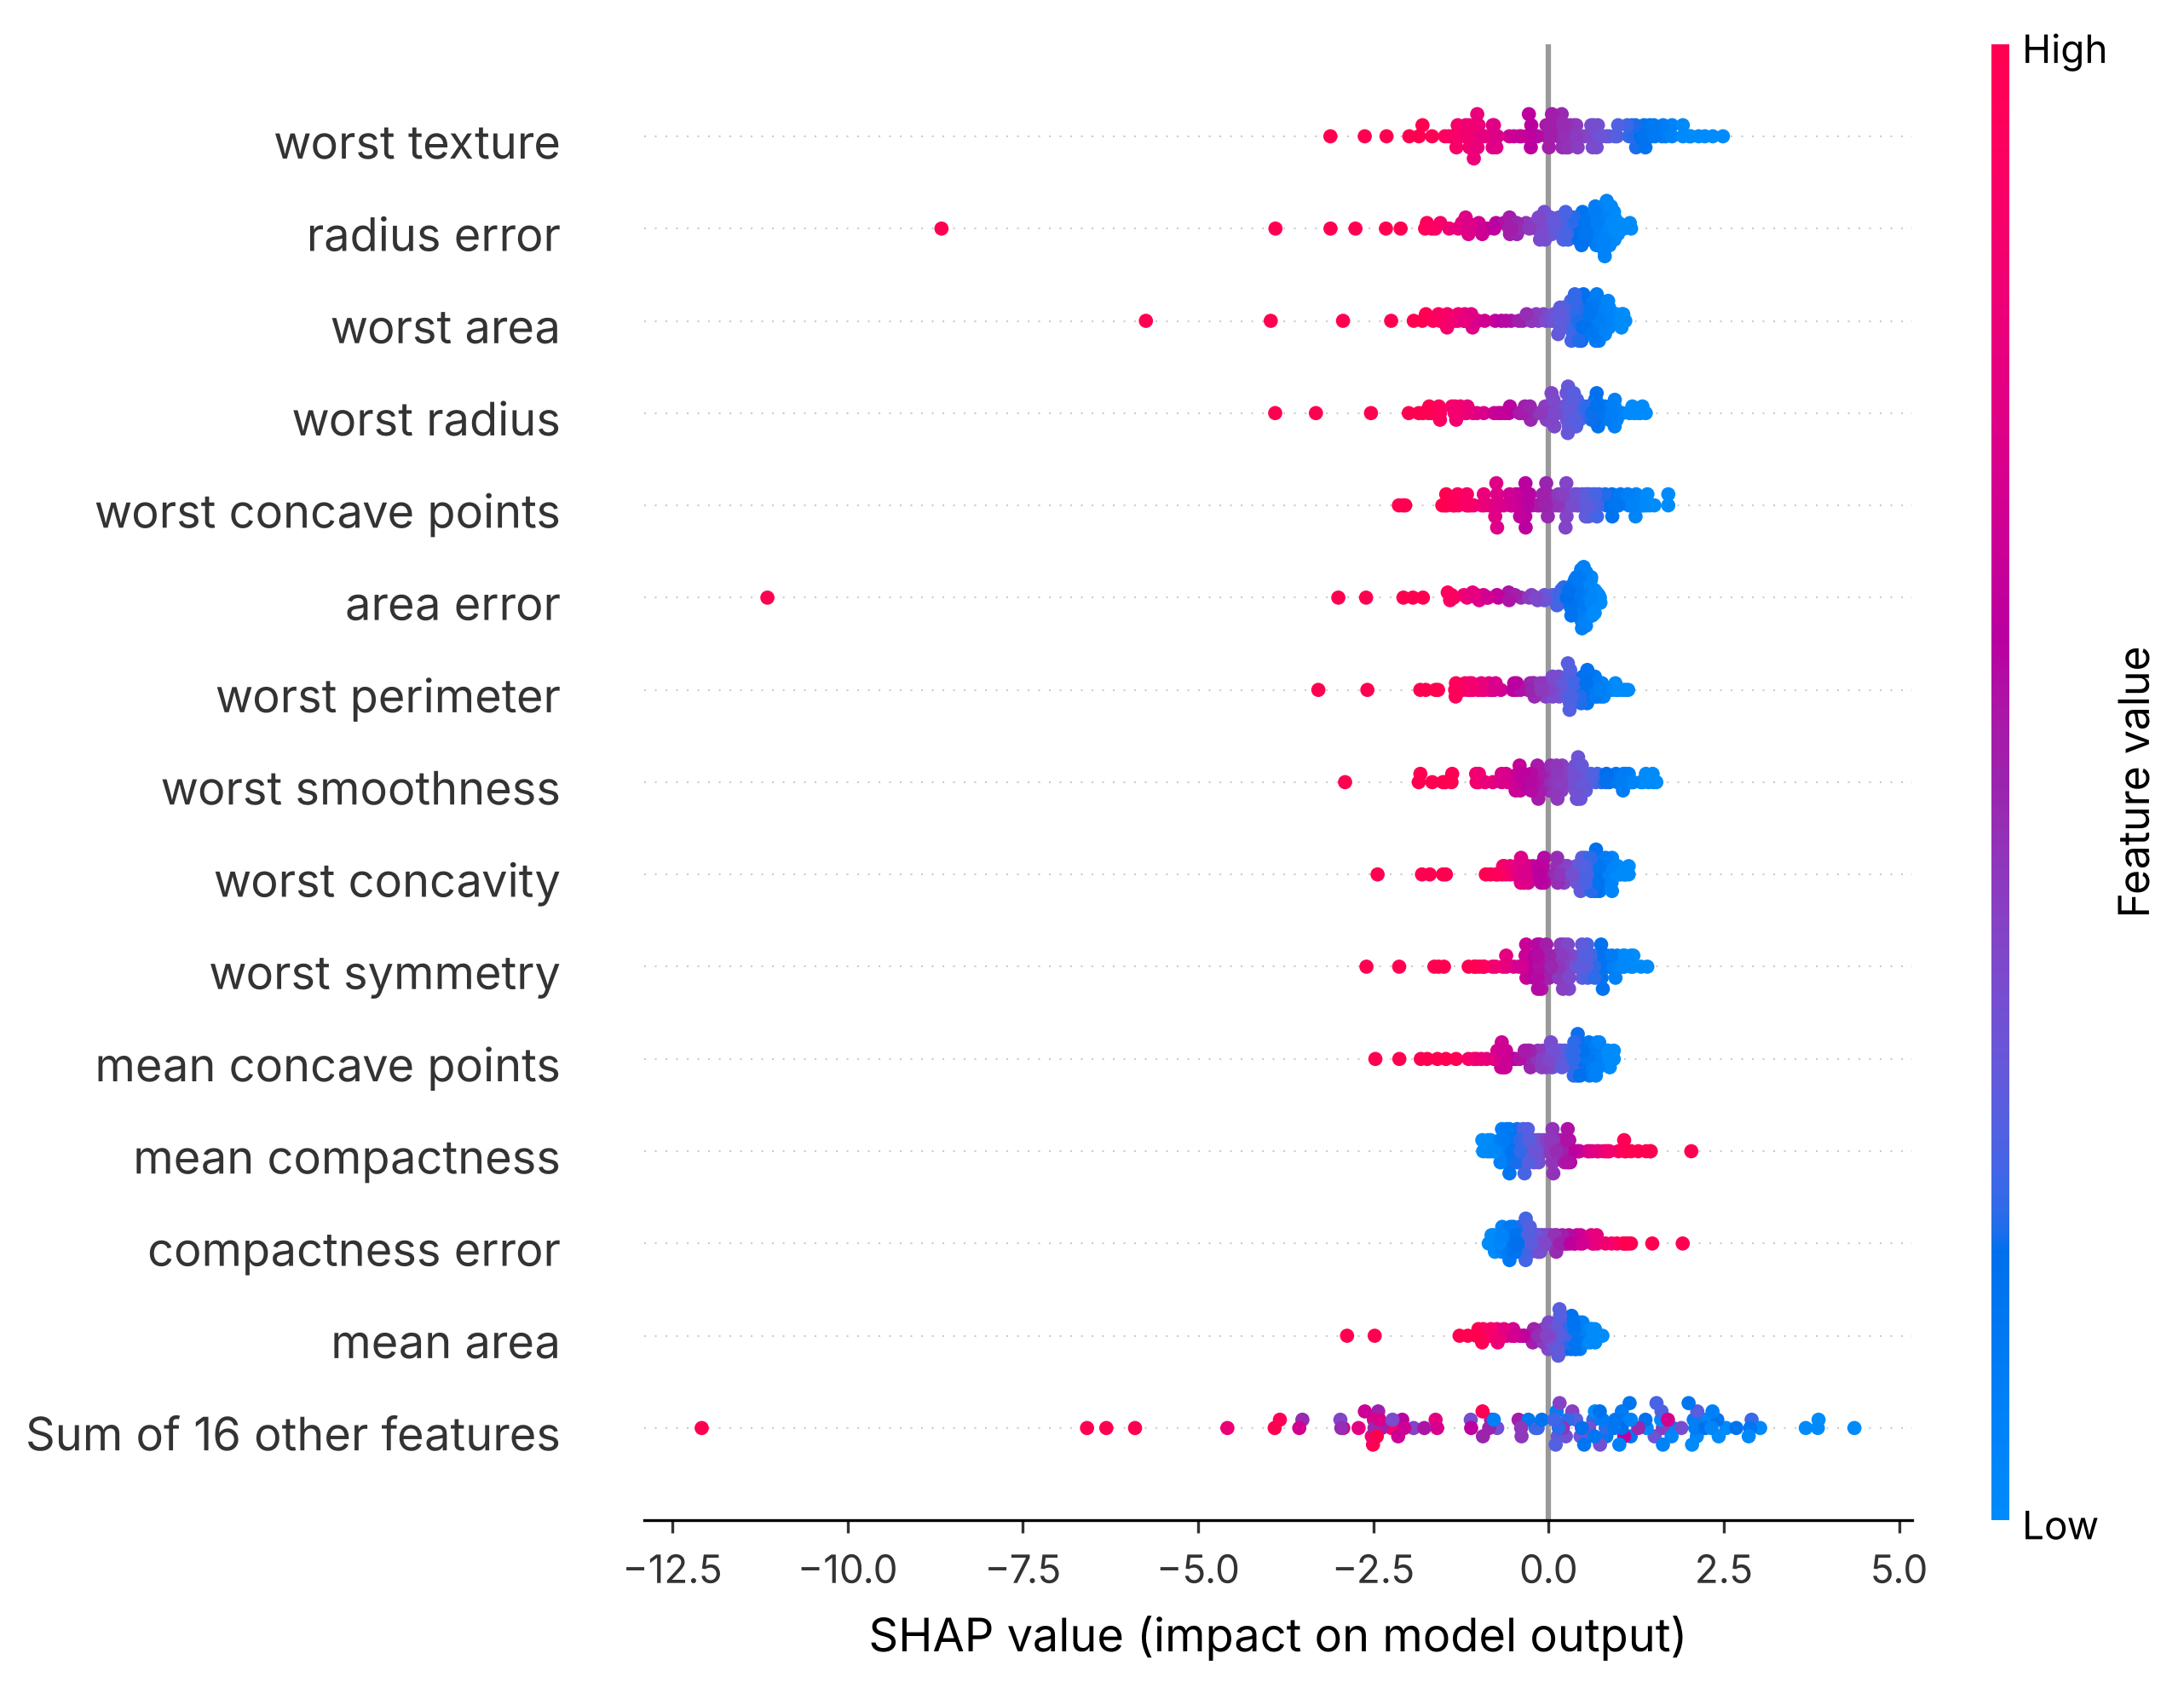

In [12]:
display(Image("results/figures/shap_resumen.png", width=650))

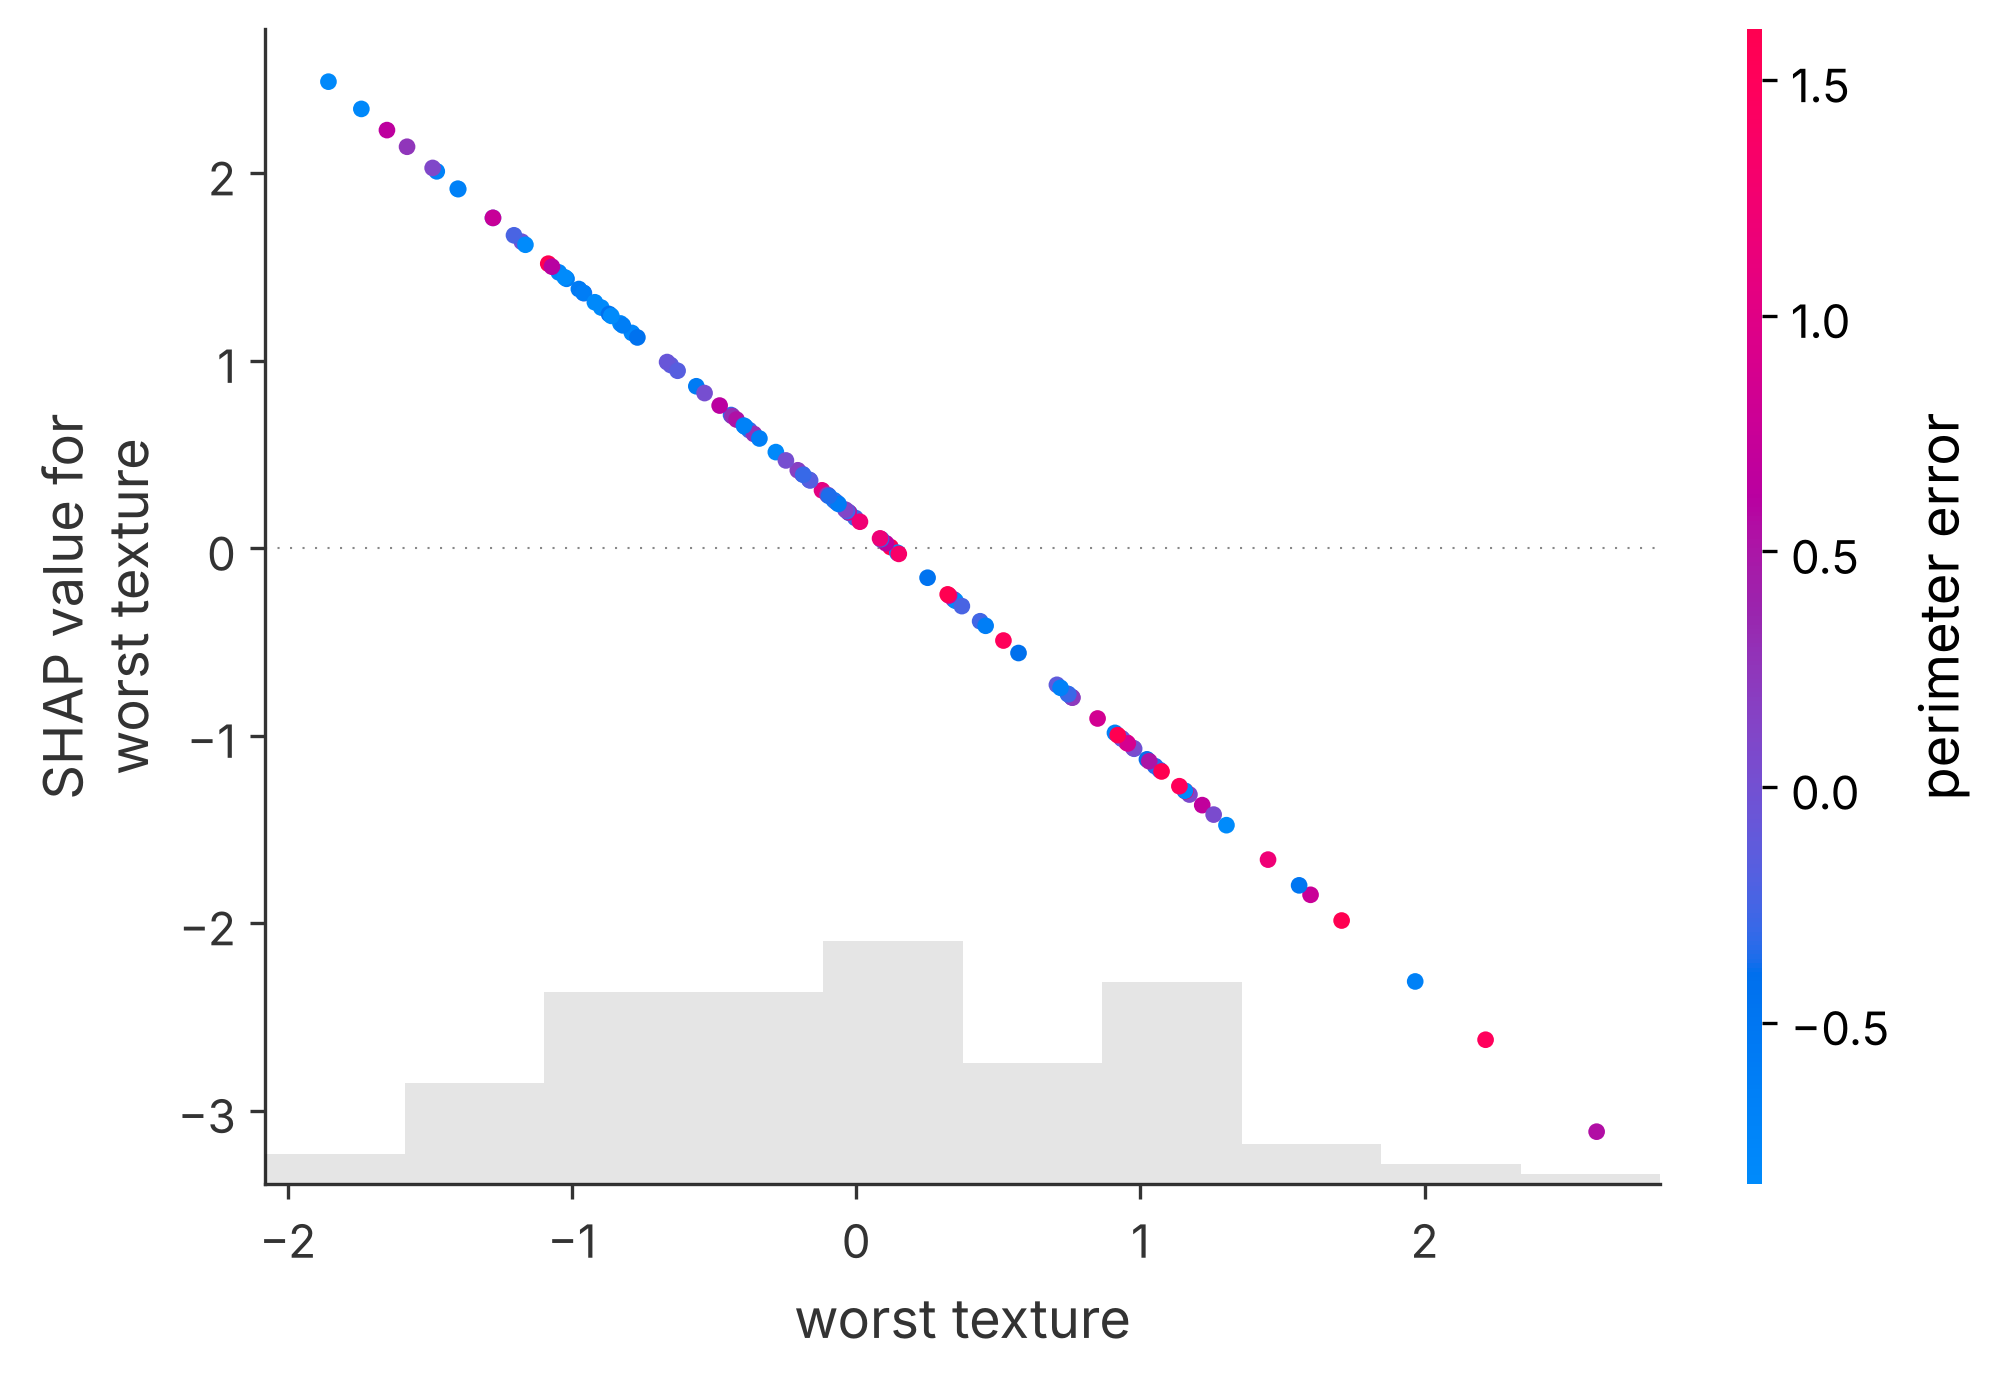

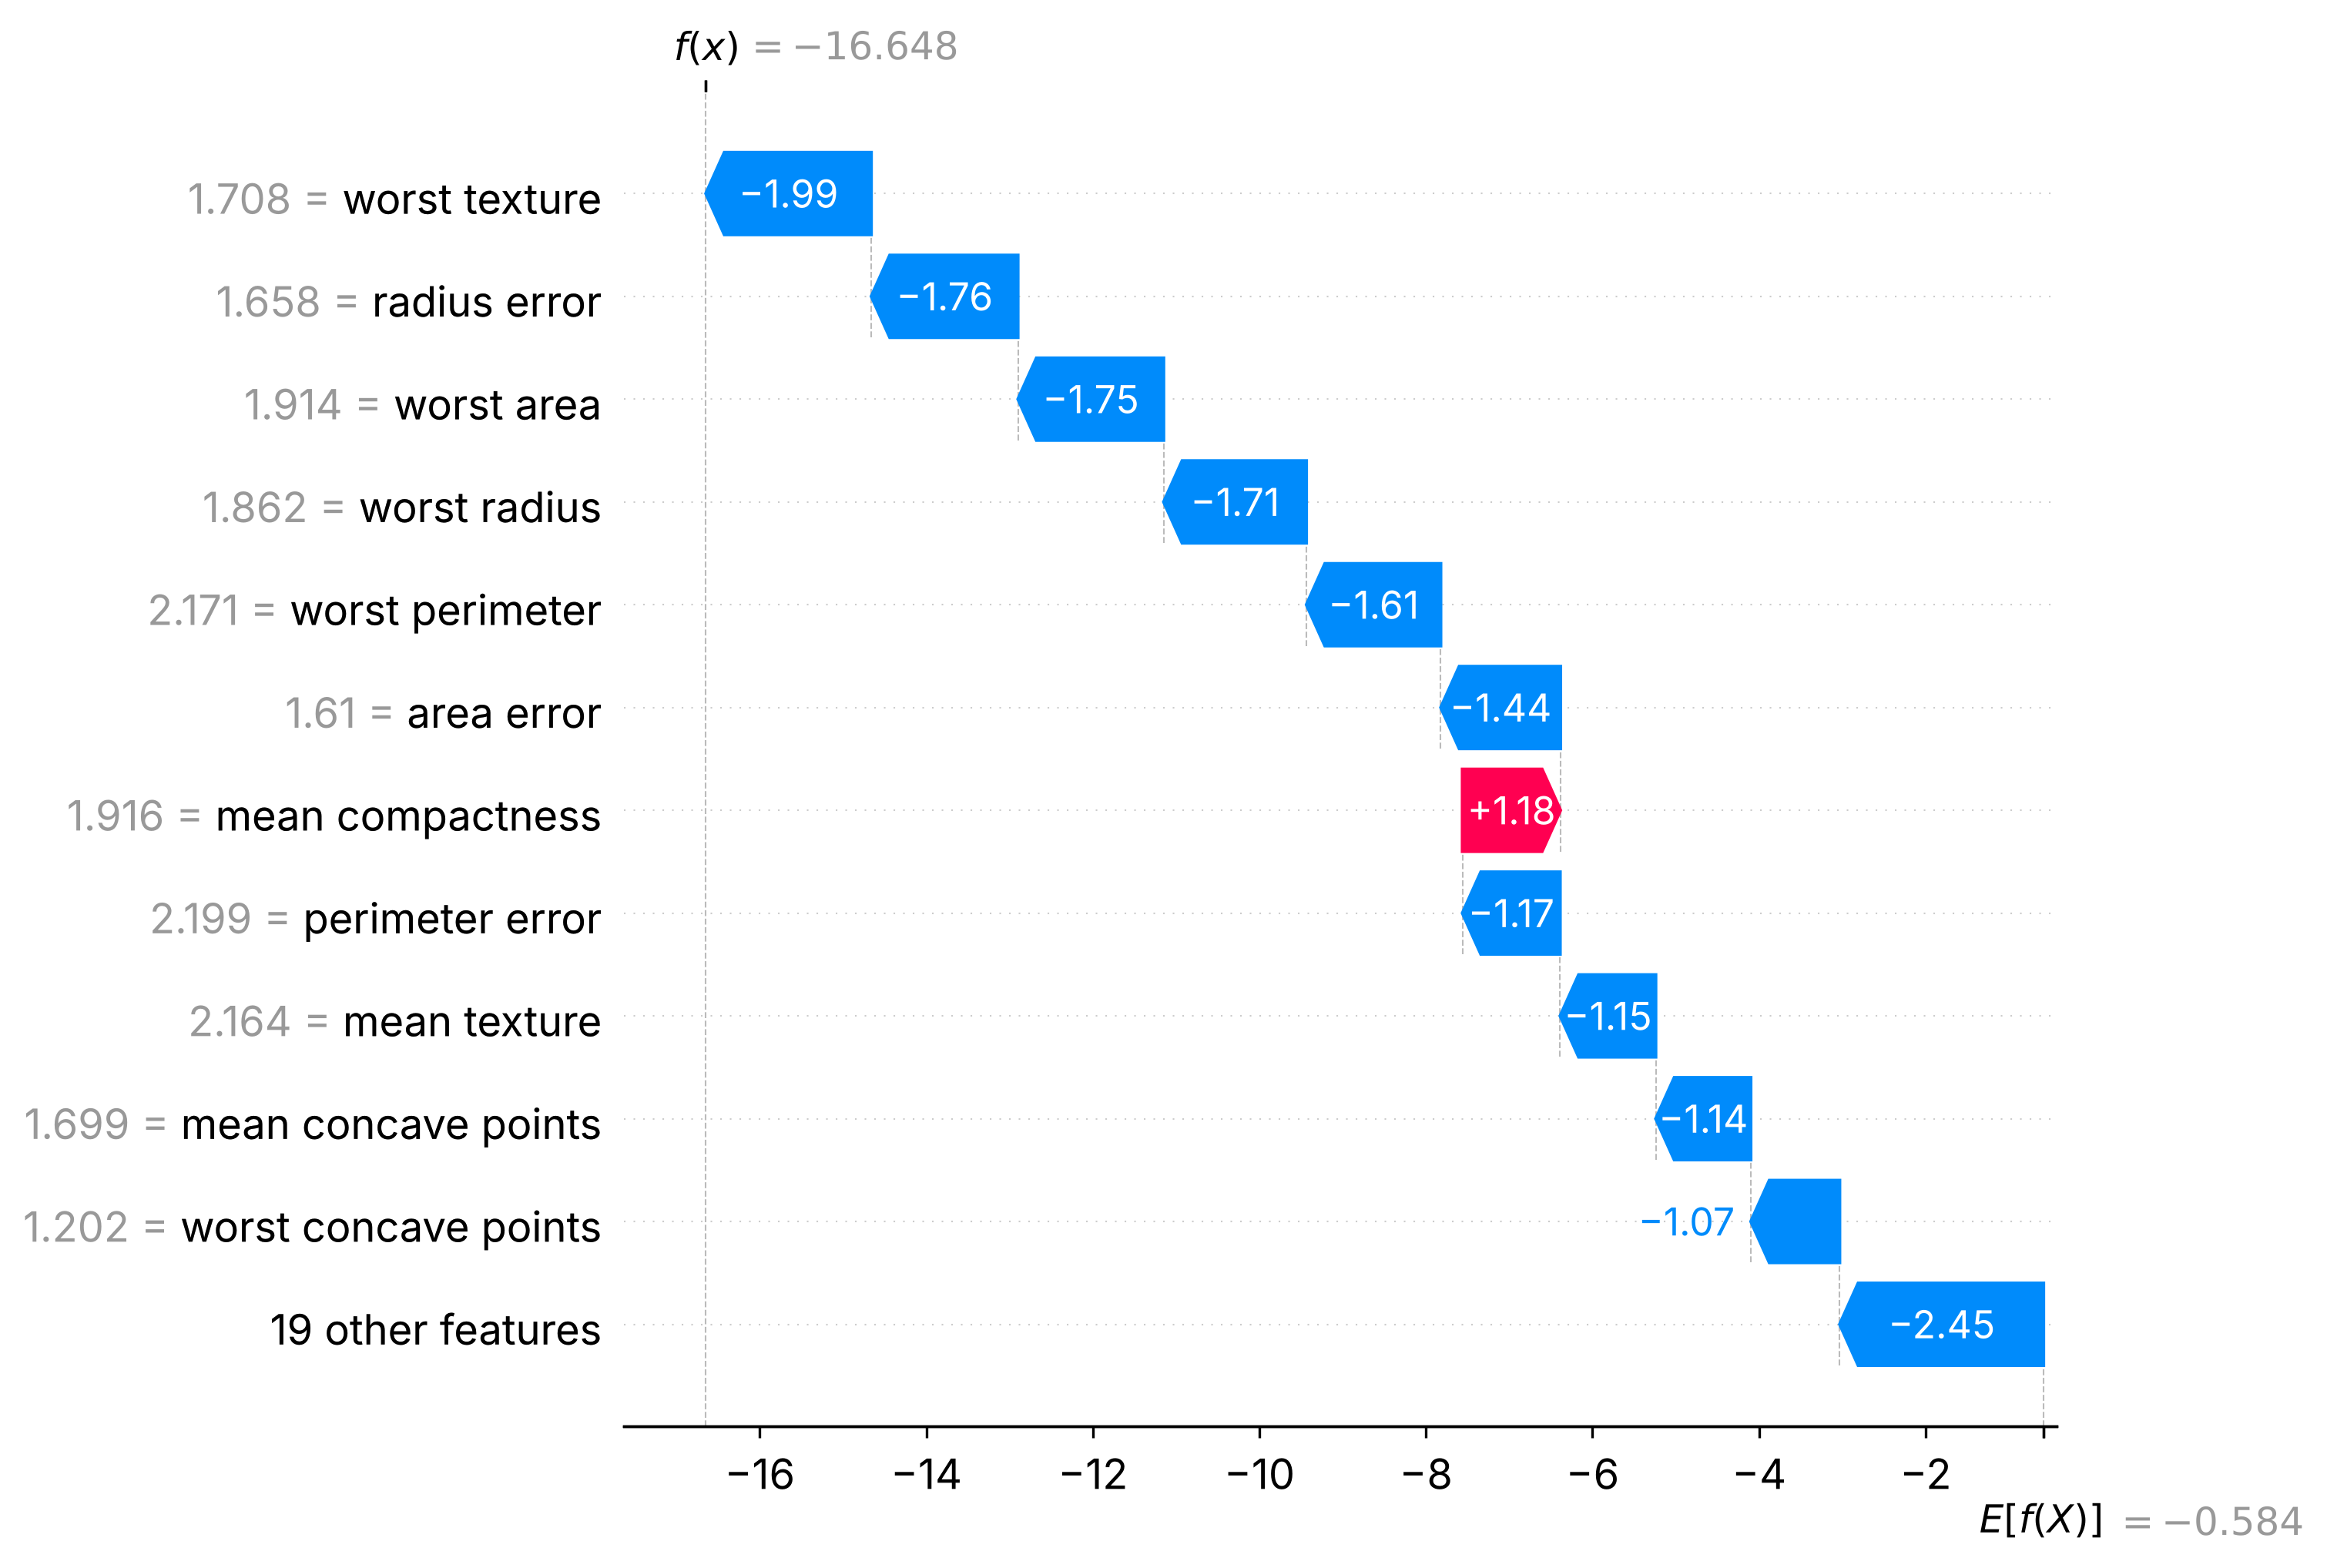

In [13]:
variable_top = imp_shap["variable"].iloc[0].replace(" ", "_")
display(Image(f"results/figures/shap_dependencia_{variable_top}.png", width=550))
display(Image("results/figures/shap_caso_0.png", width=650))

## 8. Qué llevar a tu documento

- La tabla de la batería (media ± desviación estándar y tiempo) y la figura que compara todos los modelos.
- La prueba de Friedman con su estadístico y valor p, el diagrama de diferencia crítica y, si hace falta, la tabla de Wilcoxon-Holm.
- La métrica del modelo final en prueba **con su intervalo de confianza** y la mejora frente a la línea base.
- La tabla de ablación (`results/tables/ablacion.csv`).
- Los gráficos SHAP interpretados **en el lenguaje del problema**, y en qué coinciden y en qué no con la importancia por permutación.

Ninguna cifra se escribe a mano: todas salen de `results/tables/`. Revisa tu documento con la [lista de buenas prácticas de reporte](../guias/lista-de-reporte.md).